## scHiCDiff 的结果输出

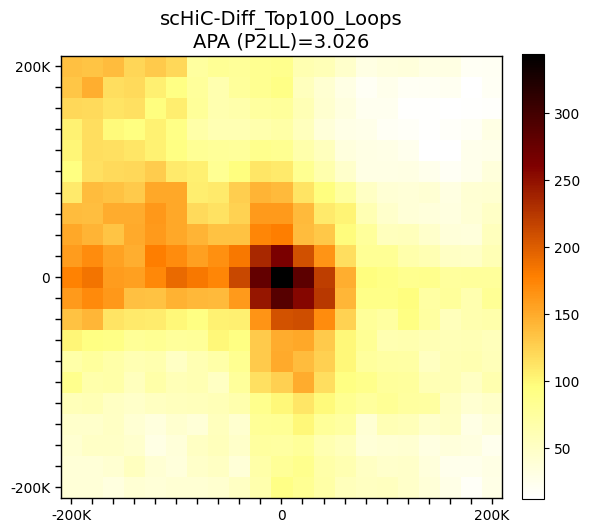

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. 配置区域 ---
SAMPLES = [
    "../../../../4_apa/right_bedpe_juicer/Top100_results/W-200kb/rawHiC_depth85/schicdiff_apa_top100/20000/chr1vchr1",
    # "../4_apa/right_bedpe_juicer/Top100_results/schicdiff_apa_top50/20000/chr1vchr1",
]

# 分辨率 20kb
RESOLUTION = 20000 

fig, axes = plt.subplots(1, len(SAMPLES), figsize=(6*len(SAMPLES), 6))
if len(SAMPLES) == 1:
    axes = [axes]

for ax, sample_path in zip(axes, SAMPLES):
    # --- 数据读取 ---
    # apa_path = os.path.join(sample_path, "normedAPA.npy")
    apa_path = os.path.join(sample_path, "APA.npy")
    if not os.path.exists(apa_path):
        apa_path = os.path.join(sample_path, "APA.npy")
    
    if not os.path.exists(apa_path):
        print(f"Warning: File not found at {apa_path}")
        continue
        
    apa = np.load(apa_path)

    # 读取 P2LL
    P2LL = None
    measures = os.path.join(sample_path, "measures.txt")
    if os.path.exists(measures):
        try:
            for line in open(measures):
                if line.strip().startswith("P2LL"):
                    P2LL = float(line.split()[1])
        except:
            pass

    # --- 2. 动态计算 Extent (这是画布的边缘) ---
    n_bins = apa.shape[0] # e.g., 21
    half_width = (n_bins * RESOLUTION) / 2 # e.g., 210,000
    
    # 这里的 extent 定义的是图像的"最外边框"，必须是物理边缘
    extent = (-half_width, half_width, -half_width, half_width)

    # --- 3. 绘图 ---
    cmap = plt.get_cmap("afmhot_r")
    # interpolation='nearest' 确保方块清晰
    im = ax.imshow(apa, cmap=cmap, origin='lower', extent=extent, aspect='equal', interpolation='nearest')

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

    # --- 4. 坐标轴设置 (关键修改：让刻度在 Bin 中心) ---
    
    # 计算第一个 Bin 的中心位置：左边缘 + 半个分辨率
    start_center = -half_width + (RESOLUTION / 2) 
    # 计算最后一个 Bin 的中心位置
    end_center = half_width - (RESOLUTION / 2)
    
    # 生成刻度：从第一个中心到最后一个中心，步长为分辨率
    # 结果示例: -200k, -180k, ..., 0, ..., 200k
    ticks = np.arange(start_center, end_center + 1, RESOLUTION)
    
    # 生成标签
    tick_labels = []
    for t in ticks:
        val_k = int(t / 1000)
        # 逻辑：
        # 1. 0 必须显示
        # 2. 整 100k 显示
        # 3. 也可以根据需要显示 ±200k (即首尾)
        if val_k == 0:
            tick_labels.append("0")
        elif t % 200000 == 0: # 每 100k 显示一次数字 (e.g. -100K, 100K)
             tick_labels.append(f"{val_k}K")
        elif abs(t) == abs(end_center): # 确保最外侧的中心也有数值标记 (e.g. 200K)
             tick_labels.append(f"{val_k}K")
        else:
            tick_labels.append("") # 其他位置只有刻度线

    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_yticks(ticks)
    ax.set_yticklabels(tick_labels, fontsize=10)
    
    # 不使用 minorticks，因为我们的 major ticks 已经对应了每个 bin
    ax.tick_params(axis='both', which='major', length=4, width=1)

    # --- 5. 标题与样式 ---
    # try:
    #     path_parts = sample_path.strip("/").split("/")
    #     sample_pure_name = path_parts[-3] 
    # except:
    #     sample_pure_name = os.path.basename(os.path.dirname(sample_path))

    title_text = f"scHiC-Diff_Top100_Loops" 
    # title_text = f"scHiCluster_Top100_Loops"
    
    if P2LL is not None:
        title_text += f"\nAPA (P2LL)={P2LL:.3f}"
        
    ax.set_title(title_text, fontsize=14)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig("./APA_scHiCDiff_Top100_Loops.png", dpi=400)
plt.show()

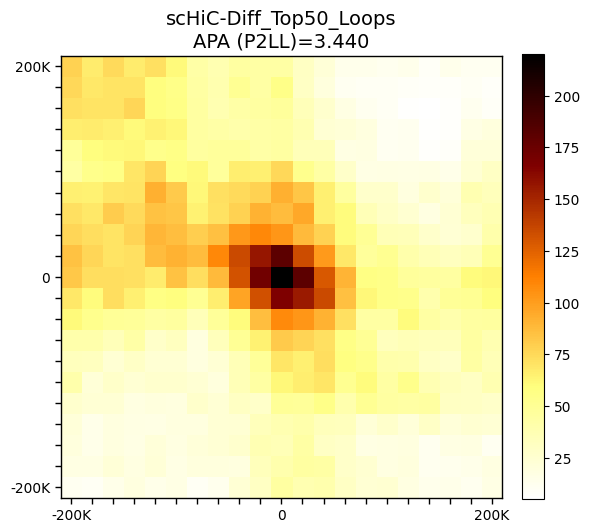

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. 配置区域 ---
SAMPLES = [
    "../../../../4_apa/right_bedpe_juicer/Top100_results/W-200kb/rawHiC_depth85/schicdiff_apa_top50/20000/chr1vchr1",
    # "../4_apa/right_bedpe_juicer/Top100_results/schicdiff_apa_top50/20000/chr1vchr1",
]

# 分辨率 20kb
RESOLUTION = 20000 

fig, axes = plt.subplots(1, len(SAMPLES), figsize=(6*len(SAMPLES), 6))
if len(SAMPLES) == 1:
    axes = [axes]

for ax, sample_path in zip(axes, SAMPLES):
    # --- 数据读取 ---
    # apa_path = os.path.join(sample_path, "normedAPA.npy")
    apa_path = os.path.join(sample_path, "APA.npy")
    if not os.path.exists(apa_path):
        apa_path = os.path.join(sample_path, "APA.npy")
    
    if not os.path.exists(apa_path):
        print(f"Warning: File not found at {apa_path}")
        continue
        
    apa = np.load(apa_path)

    # 读取 P2LL
    P2LL = None
    measures = os.path.join(sample_path, "measures.txt")
    if os.path.exists(measures):
        try:
            for line in open(measures):
                if line.strip().startswith("P2LL"):
                    P2LL = float(line.split()[1])
        except:
            pass

    # --- 2. 动态计算 Extent (这是画布的边缘) ---
    n_bins = apa.shape[0] # e.g., 21
    half_width = (n_bins * RESOLUTION) / 2 # e.g., 210,000
    
    # 这里的 extent 定义的是图像的"最外边框"，必须是物理边缘
    extent = (-half_width, half_width, -half_width, half_width)

    # --- 3. 绘图 ---
    cmap = plt.get_cmap("afmhot_r")
    # interpolation='nearest' 确保方块清晰
    im = ax.imshow(apa, cmap=cmap, origin='lower', extent=extent, aspect='equal', interpolation='nearest')

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

    # --- 4. 坐标轴设置 (关键修改：让刻度在 Bin 中心) ---
    
    # 计算第一个 Bin 的中心位置：左边缘 + 半个分辨率
    start_center = -half_width + (RESOLUTION / 2) 
    # 计算最后一个 Bin 的中心位置
    end_center = half_width - (RESOLUTION / 2)
    
    # 生成刻度：从第一个中心到最后一个中心，步长为分辨率
    # 结果示例: -200k, -180k, ..., 0, ..., 200k
    ticks = np.arange(start_center, end_center + 1, RESOLUTION)
    
    # 生成标签
    tick_labels = []
    for t in ticks:
        val_k = int(t / 1000)
        # 逻辑：
        # 1. 0 必须显示
        # 2. 整 100k 显示
        # 3. 也可以根据需要显示 ±200k (即首尾)
        if val_k == 0:
            tick_labels.append("0")
        elif t % 200000 == 0: # 每 100k 显示一次数字 (e.g. -100K, 100K)
             tick_labels.append(f"{val_k}K")
        elif abs(t) == abs(end_center): # 确保最外侧的中心也有数值标记 (e.g. 200K)
             tick_labels.append(f"{val_k}K")
        else:
            tick_labels.append("") # 其他位置只有刻度线

    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_yticks(ticks)
    ax.set_yticklabels(tick_labels, fontsize=10)
    
    # 不使用 minorticks，因为我们的 major ticks 已经对应了每个 bin
    ax.tick_params(axis='both', which='major', length=4, width=1)

    # --- 5. 标题与样式 ---
    # try:
    #     path_parts = sample_path.strip("/").split("/")
    #     sample_pure_name = path_parts[-3] 
    # except:
    #     sample_pure_name = os.path.basename(os.path.dirname(sample_path))

    title_text = f"scHiC-Diff_Top50_Loops" 
    # title_text = f"scHiCluster_Top100_Loops"
    
    if P2LL is not None:
        title_text += f"\nAPA (P2LL)={P2LL:.3f}"
        
    ax.set_title(title_text, fontsize=14)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig("./APA_scHiCDiff_Top50_Loops.png", dpi=400)
plt.show()

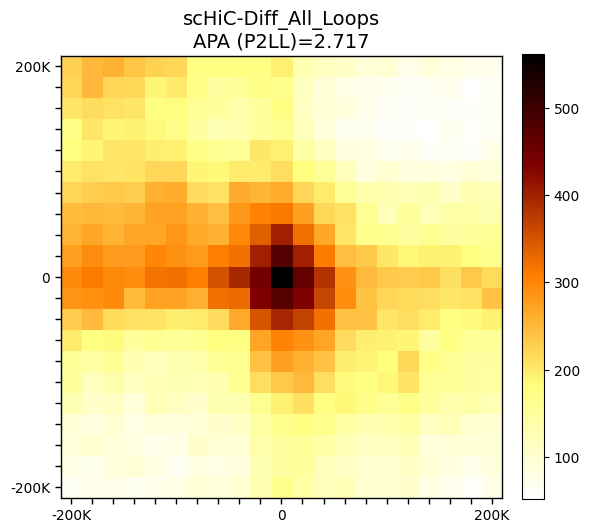

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. 配置区域 ---
SAMPLES = [
    "../../../../4_apa/right_bedpe_juicer/Top100_results/W-200kb/rawHiC_depth85/schicdiff_earlyNeurons_476cells/20000/chr1vchr1",
    # "../4_apa/right_bedpe_juicer/Top100_results/schicdiff_apa_top50/20000/chr1vchr1",
]

# 分辨率 20kb
RESOLUTION = 20000 

fig, axes = plt.subplots(1, len(SAMPLES), figsize=(6*len(SAMPLES), 6))
if len(SAMPLES) == 1:
    axes = [axes]

for ax, sample_path in zip(axes, SAMPLES):
    # --- 数据读取 ---
    # apa_path = os.path.join(sample_path, "normedAPA.npy")
    apa_path = os.path.join(sample_path, "APA.npy")
    if not os.path.exists(apa_path):
        apa_path = os.path.join(sample_path, "APA.npy")
    
    if not os.path.exists(apa_path):
        print(f"Warning: File not found at {apa_path}")
        continue
        
    apa = np.load(apa_path)

    # 读取 P2LL
    P2LL = None
    measures = os.path.join(sample_path, "measures.txt")
    if os.path.exists(measures):
        try:
            for line in open(measures):
                if line.strip().startswith("P2LL"):
                    P2LL = float(line.split()[1])
        except:
            pass

    # --- 2. 动态计算 Extent (这是画布的边缘) ---
    n_bins = apa.shape[0] # e.g., 21
    half_width = (n_bins * RESOLUTION) / 2 # e.g., 210,000
    
    # 这里的 extent 定义的是图像的"最外边框"，必须是物理边缘
    extent = (-half_width, half_width, -half_width, half_width)

    # --- 3. 绘图 ---
    cmap = plt.get_cmap("afmhot_r")
    # interpolation='nearest' 确保方块清晰
    im = ax.imshow(apa, cmap=cmap, origin='lower', extent=extent, aspect='equal', interpolation='nearest')

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

    # --- 4. 坐标轴设置 (关键修改：让刻度在 Bin 中心) ---
    
    # 计算第一个 Bin 的中心位置：左边缘 + 半个分辨率
    start_center = -half_width + (RESOLUTION / 2) 
    # 计算最后一个 Bin 的中心位置
    end_center = half_width - (RESOLUTION / 2)
    
    # 生成刻度：从第一个中心到最后一个中心，步长为分辨率
    # 结果示例: -200k, -180k, ..., 0, ..., 200k
    ticks = np.arange(start_center, end_center + 1, RESOLUTION)
    
    # 生成标签
    tick_labels = []
    for t in ticks:
        val_k = int(t / 1000)
        # 逻辑：
        # 1. 0 必须显示
        # 2. 整 100k 显示
        # 3. 也可以根据需要显示 ±200k (即首尾)
        if val_k == 0:
            tick_labels.append("0")
        elif t % 200000 == 0: # 每 100k 显示一次数字 (e.g. -100K, 100K)
             tick_labels.append(f"{val_k}K")
        elif abs(t) == abs(end_center): # 确保最外侧的中心也有数值标记 (e.g. 200K)
             tick_labels.append(f"{val_k}K")
        else:
            tick_labels.append("") # 其他位置只有刻度线

    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_yticks(ticks)
    ax.set_yticklabels(tick_labels, fontsize=10)
    
    # 不使用 minorticks，因为我们的 major ticks 已经对应了每个 bin
    ax.tick_params(axis='both', which='major', length=4, width=1)

    # --- 5. 标题与样式 ---
    # try:
    #     path_parts = sample_path.strip("/").split("/")
    #     sample_pure_name = path_parts[-3] 
    # except:
    #     sample_pure_name = os.path.basename(os.path.dirname(sample_path))

    # title_text = f"scHiCDiff_Top100_Loops" 
    title_text = f"scHiC-Diff_All_Loops"
    
    if P2LL is not None:
        title_text += f"\nAPA (P2LL)={P2LL:.3f}"
        
    ax.set_title(title_text, fontsize=14)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig("./APA_scHiCDiff_All_Loops.png", dpi=400)
plt.show()

## scHiCluster 的结果输出

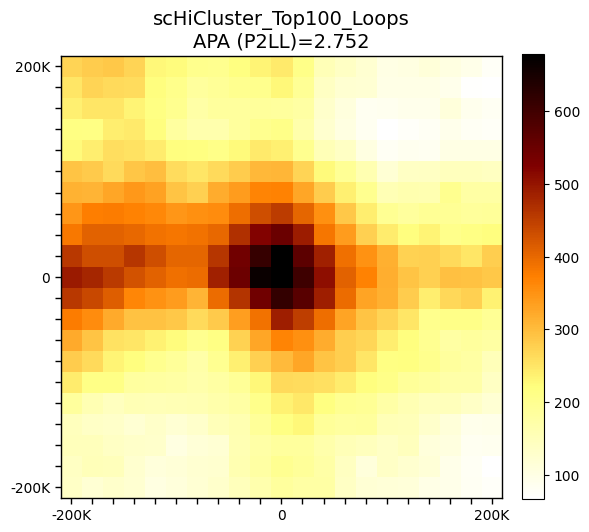

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. 配置区域 ---
SAMPLES = [
    "../4_apa/right_bedpe_juicer/Top100_results/W-200kb/rawHiC_depth85/schicluster_apa_top100/20000/chr1vchr1",
    # "../4_apa/right_bedpe_juicer/Top100_results/schicdiff_apa_top50/20000/chr1vchr1",
]

# 分辨率 20kb
RESOLUTION = 20000 

fig, axes = plt.subplots(1, len(SAMPLES), figsize=(6*len(SAMPLES), 6))
if len(SAMPLES) == 1:
    axes = [axes]

for ax, sample_path in zip(axes, SAMPLES):
    # --- 数据读取 ---
    # apa_path = os.path.join(sample_path, "normedAPA.npy")
    apa_path = os.path.join(sample_path, "APA.npy")
    if not os.path.exists(apa_path):
        apa_path = os.path.join(sample_path, "APA.npy")
    
    if not os.path.exists(apa_path):
        print(f"Warning: File not found at {apa_path}")
        continue
        
    apa = np.load(apa_path)

    # 读取 P2LL
    P2LL = None
    measures = os.path.join(sample_path, "measures.txt")
    if os.path.exists(measures):
        try:
            for line in open(measures):
                if line.strip().startswith("P2LL"):
                    P2LL = float(line.split()[1])
        except:
            pass

    # --- 2. 动态计算 Extent (这是画布的边缘) ---
    n_bins = apa.shape[0] # e.g., 21
    half_width = (n_bins * RESOLUTION) / 2 # e.g., 210,000
    
    # 这里的 extent 定义的是图像的"最外边框"，必须是物理边缘
    extent = (-half_width, half_width, -half_width, half_width)

    # --- 3. 绘图 ---
    cmap = plt.get_cmap("afmhot_r")
    # interpolation='nearest' 确保方块清晰
    im = ax.imshow(apa, cmap=cmap, origin='lower', extent=extent, aspect='equal', interpolation='nearest')

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

    # --- 4. 坐标轴设置 (关键修改：让刻度在 Bin 中心) ---
    
    # 计算第一个 Bin 的中心位置：左边缘 + 半个分辨率
    start_center = -half_width + (RESOLUTION / 2) 
    # 计算最后一个 Bin 的中心位置
    end_center = half_width - (RESOLUTION / 2)
    
    # 生成刻度：从第一个中心到最后一个中心，步长为分辨率
    # 结果示例: -200k, -180k, ..., 0, ..., 200k
    ticks = np.arange(start_center, end_center + 1, RESOLUTION)
    
    # 生成标签
    tick_labels = []
    for t in ticks:
        val_k = int(t / 1000)
        # 逻辑：
        # 1. 0 必须显示
        # 2. 整 100k 显示
        # 3. 也可以根据需要显示 ±200k (即首尾)
        if val_k == 0:
            tick_labels.append("0")
        elif t % 200000 == 0: # 每 100k 显示一次数字 (e.g. -100K, 100K)
             tick_labels.append(f"{val_k}K")
        elif abs(t) == abs(end_center): # 确保最外侧的中心也有数值标记 (e.g. 200K)
             tick_labels.append(f"{val_k}K")
        else:
            tick_labels.append("") # 其他位置只有刻度线

    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_yticks(ticks)
    ax.set_yticklabels(tick_labels, fontsize=10)
    
    # 不使用 minorticks，因为我们的 major ticks 已经对应了每个 bin
    ax.tick_params(axis='both', which='major', length=4, width=1)

    # --- 5. 标题与样式 ---
    # try:
    #     path_parts = sample_path.strip("/").split("/")
    #     sample_pure_name = path_parts[-3] 
    # except:
    #     sample_pure_name = os.path.basename(os.path.dirname(sample_path))

    # title_text = f"scHiCDiff_Top100_Loops" 
    title_text = f"scHiCluster_Top100_Loops"
    
    if P2LL is not None:
        title_text += f"\nAPA (P2LL)={P2LL:.3f}"
        
    ax.set_title(title_text, fontsize=14)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig("./APA_scHiCluster_Top100_Loops.png", dpi=400)
plt.show()

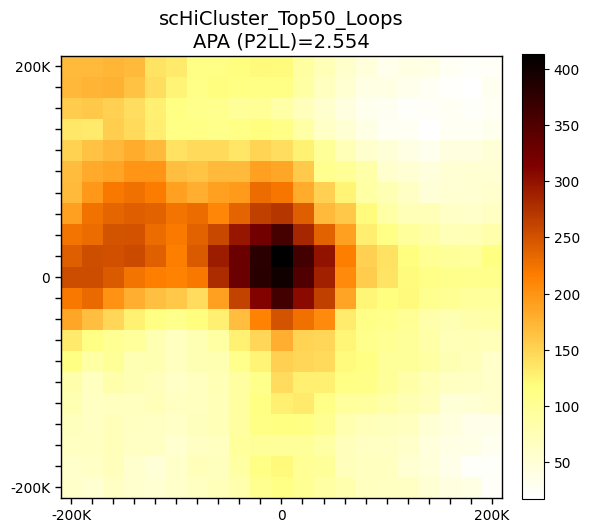

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. 配置区域 ---
SAMPLES = [
    "../4_apa/right_bedpe_juicer/Top100_results/W-200kb/rawHiC_depth85/schicluster_apa_top50/20000/chr1vchr1",
    # "../4_apa/right_bedpe_juicer/Top100_results/schicdiff_apa_top50/20000/chr1vchr1",
]

# 分辨率 20kb
RESOLUTION = 20000 

fig, axes = plt.subplots(1, len(SAMPLES), figsize=(6*len(SAMPLES), 6))
if len(SAMPLES) == 1:
    axes = [axes]

for ax, sample_path in zip(axes, SAMPLES):
    # --- 数据读取 ---
    # apa_path = os.path.join(sample_path, "normedAPA.npy")
    apa_path = os.path.join(sample_path, "APA.npy")
    if not os.path.exists(apa_path):
        apa_path = os.path.join(sample_path, "APA.npy")
    
    if not os.path.exists(apa_path):
        print(f"Warning: File not found at {apa_path}")
        continue
        
    apa = np.load(apa_path)

    # 读取 P2LL
    P2LL = None
    measures = os.path.join(sample_path, "measures.txt")
    if os.path.exists(measures):
        try:
            for line in open(measures):
                if line.strip().startswith("P2LL"):
                    P2LL = float(line.split()[1])
        except:
            pass

    # --- 2. 动态计算 Extent (这是画布的边缘) ---
    n_bins = apa.shape[0] # e.g., 21
    half_width = (n_bins * RESOLUTION) / 2 # e.g., 210,000
    
    # 这里的 extent 定义的是图像的"最外边框"，必须是物理边缘
    extent = (-half_width, half_width, -half_width, half_width)

    # --- 3. 绘图 ---
    cmap = plt.get_cmap("afmhot_r")
    # interpolation='nearest' 确保方块清晰
    im = ax.imshow(apa, cmap=cmap, origin='lower', extent=extent, aspect='equal', interpolation='nearest')

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

    # --- 4. 坐标轴设置 (关键修改：让刻度在 Bin 中心) ---
    
    # 计算第一个 Bin 的中心位置：左边缘 + 半个分辨率
    start_center = -half_width + (RESOLUTION / 2) 
    # 计算最后一个 Bin 的中心位置
    end_center = half_width - (RESOLUTION / 2)
    
    # 生成刻度：从第一个中心到最后一个中心，步长为分辨率
    # 结果示例: -200k, -180k, ..., 0, ..., 200k
    ticks = np.arange(start_center, end_center + 1, RESOLUTION)
    
    # 生成标签
    tick_labels = []
    for t in ticks:
        val_k = int(t / 1000)
        # 逻辑：
        # 1. 0 必须显示
        # 2. 整 100k 显示
        # 3. 也可以根据需要显示 ±200k (即首尾)
        if val_k == 0:
            tick_labels.append("0")
        elif t % 200000 == 0: # 每 100k 显示一次数字 (e.g. -100K, 100K)
             tick_labels.append(f"{val_k}K")
        elif abs(t) == abs(end_center): # 确保最外侧的中心也有数值标记 (e.g. 200K)
             tick_labels.append(f"{val_k}K")
        else:
            tick_labels.append("") # 其他位置只有刻度线

    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_yticks(ticks)
    ax.set_yticklabels(tick_labels, fontsize=10)
    
    # 不使用 minorticks，因为我们的 major ticks 已经对应了每个 bin
    ax.tick_params(axis='both', which='major', length=4, width=1)

    # --- 5. 标题与样式 ---
    # try:
    #     path_parts = sample_path.strip("/").split("/")
    #     sample_pure_name = path_parts[-3] 
    # except:
    #     sample_pure_name = os.path.basename(os.path.dirname(sample_path))

    # title_text = f"scHiCDiff_Top100_Loops" 
    title_text = f"scHiCluster_Top50_Loops"
    
    if P2LL is not None:
        title_text += f"\nAPA (P2LL)={P2LL:.3f}"
        
    ax.set_title(title_text, fontsize=14)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig("./APA_scHiCluster_Top50_Loops.png", dpi=400)
plt.show()

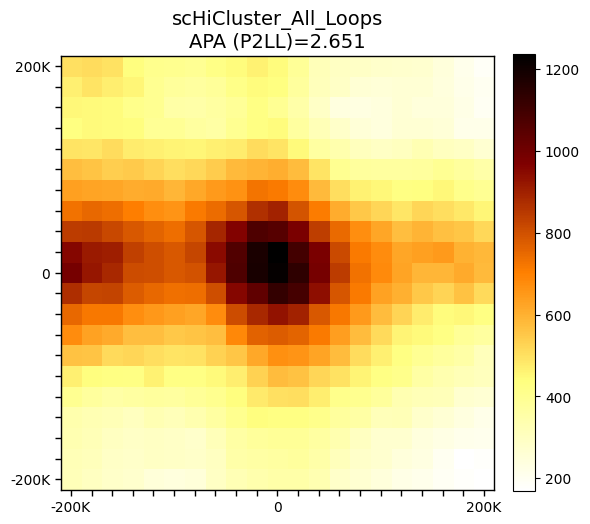

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. 配置区域 ---
SAMPLES = [
    "../4_apa/right_bedpe_juicer/Top100_results/W-200kb/rawHiC_depth85/schicluster_earlyNeurons_476cells/20000/chr1vchr1",
    # "../4_apa/right_bedpe_juicer/Top100_results/schicdiff_apa_top50/20000/chr1vchr1",
]

# 分辨率 20kb
RESOLUTION = 20000 

fig, axes = plt.subplots(1, len(SAMPLES), figsize=(6*len(SAMPLES), 6))
if len(SAMPLES) == 1:
    axes = [axes]

for ax, sample_path in zip(axes, SAMPLES):
    # --- 数据读取 ---
    # apa_path = os.path.join(sample_path, "normedAPA.npy")
    apa_path = os.path.join(sample_path, "APA.npy")
    if not os.path.exists(apa_path):
        apa_path = os.path.join(sample_path, "APA.npy")
    
    if not os.path.exists(apa_path):
        print(f"Warning: File not found at {apa_path}")
        continue
        
    apa = np.load(apa_path)

    # 读取 P2LL
    P2LL = None
    measures = os.path.join(sample_path, "measures.txt")
    if os.path.exists(measures):
        try:
            for line in open(measures):
                if line.strip().startswith("P2LL"):
                    P2LL = float(line.split()[1])
        except:
            pass

    # --- 2. 动态计算 Extent (这是画布的边缘) ---
    n_bins = apa.shape[0] # e.g., 21
    half_width = (n_bins * RESOLUTION) / 2 # e.g., 210,000
    
    # 这里的 extent 定义的是图像的"最外边框"，必须是物理边缘
    extent = (-half_width, half_width, -half_width, half_width)

    # --- 3. 绘图 ---
    cmap = plt.get_cmap("afmhot_r")
    # interpolation='nearest' 确保方块清晰
    im = ax.imshow(apa, cmap=cmap, origin='lower', extent=extent, aspect='equal', interpolation='nearest')

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)

    # --- 4. 坐标轴设置 (关键修改：让刻度在 Bin 中心) ---
    
    # 计算第一个 Bin 的中心位置：左边缘 + 半个分辨率
    start_center = -half_width + (RESOLUTION / 2) 
    # 计算最后一个 Bin 的中心位置
    end_center = half_width - (RESOLUTION / 2)
    
    # 生成刻度：从第一个中心到最后一个中心，步长为分辨率
    # 结果示例: -200k, -180k, ..., 0, ..., 200k
    ticks = np.arange(start_center, end_center + 1, RESOLUTION)
    
    # 生成标签
    tick_labels = []
    for t in ticks:
        val_k = int(t / 1000)
        # 逻辑：
        # 1. 0 必须显示
        # 2. 整 100k 显示
        # 3. 也可以根据需要显示 ±200k (即首尾)
        if val_k == 0:
            tick_labels.append("0")
        elif t % 200000 == 0: # 每 100k 显示一次数字 (e.g. -100K, 100K)
             tick_labels.append(f"{val_k}K")
        elif abs(t) == abs(end_center): # 确保最外侧的中心也有数值标记 (e.g. 200K)
             tick_labels.append(f"{val_k}K")
        else:
            tick_labels.append("") # 其他位置只有刻度线

    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_yticks(ticks)
    ax.set_yticklabels(tick_labels, fontsize=10)
    
    # 不使用 minorticks，因为我们的 major ticks 已经对应了每个 bin
    ax.tick_params(axis='both', which='major', length=4, width=1)

    # --- 5. 标题与样式 ---
    # try:
    #     path_parts = sample_path.strip("/").split("/")
    #     sample_pure_name = path_parts[-3] 
    # except:
    #     sample_pure_name = os.path.basename(os.path.dirname(sample_path))

    # title_text = f"scHiCDiff_Top100_Loops" 
    title_text = f"scHiCluster_All_Loops"
    
    if P2LL is not None:
        title_text += f"\nAPA (P2LL)={P2LL:.3f}"
        
    ax.set_title(title_text, fontsize=14)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig("./APA_scHiCluster_All_Loops.png", dpi=400)
plt.show()